# Tutorial: Parametric GNFW Profile for tSZ Power Spectrum & Cluster Counts

This notebook demonstrates how to use the `parametric_profile` module, which
replaces the fixed Arnaud et al. pressure-profile normalisation with:

$$
y_0(M,z) = 10^{A_{\rm SZ}}\,\left(\frac{M/B}{0.7\times 3\times10^{14}}\right)^{\!\alpha_{\rm SZ}}\!
E(z)^{2}\,\left(\frac{h}{0.7}\right)^{-0.5}
$$

where $A_{\rm SZ}$ and $\alpha_{\rm SZ}$ are free parameters.

**Sections covered:**
1. Setup & initialisation
2. Parametric $y_0$ and SNR
3. Total (full-sky) tSZ power spectrum
4. Masked (unresolved) tSZ power spectrum
5. Total number of resolved clusters
6. Binned cluster counts in $(z, q)$ bins

## 1. Setup & Initialisation

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

import tszpower as tsz

2026-02-13 20:27:30.881784: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
/scratch/scratch-lxu/tszsbi/tszpower/__init__.py:1: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  from .config import classy_sz


In [2]:
# Cosmological + GNFW parameters (Planck-like)
allpars = {
    'omega_b': 0.02242,
    'omega_cdm':  0.1193,
    'H0': 67.66,
    'tau_reio': 0.0544,
    'ln10^{10}A_s': 2.9718,
    'n_s': 0.9665,
    "cosmo_model": 0,
    "B": 1.41,

    'M_min': 1e14 * 0.6766,
    'M_max': 1e16 * 0.6766,

    'z_min': 0.005,
    'z_max': 3.0,

    "P0GNFW": 8.130,
    "c500": 1.156,
    "gammaGNFW": 0.3292,
    "alphaGNFW": 1.0620,
    "betaGNFW": 5.4807,

    'jax': 1,
}

tsz.classy_sz.set(allpars)
tsz.initialise()

/tmp/ipykernel_724835/144774747.py:28: DeprecationWarning: compute_class_szfast is deprecated. Use initialize_classy_szfast instead.
  tsz.initialise()


In [3]:
# Parametric amplitude parameters (fitted values from test_tszpower.ipynb)
A_SZ = -4.237295339715123
alpha_SZ = 1.12

# Completeness / scatter parameters
sigma_lnY = 0.173   # intrinsic log-normal scatter
q_cat = 5.0          # SNR detection threshold
f_sky = 1.0          # sky fraction

print(f"A_SZ      = {A_SZ}")
print(f"alpha_SZ  = {alpha_SZ}")
print(f"sigma_lnY = {sigma_lnY}")
print(f"q_cat     = {q_cat}")
print(f"f_sky     = {f_sky}")

A_SZ      = -4.237295339715123
alpha_SZ  = 1.12
sigma_lnY = 0.173
q_cat     = 5.0
f_sky     = 1.0


In [4]:
# Verify ratio used in PS/CNC: should be ~1 when A_SZ matches Arnaud (y0 curves agree).
from tszpower.parametric_profile import _y0_ratio
ratio_at_point = float(_y0_ratio(1e15 * 0.6766, 0.3, A_SZ, alpha_SZ, params_values_dict=allpars))
print(f"Ratio y0_param/y0_orig at M=1e15*h, z=0.3: {ratio_at_point:.6f}  (expect ~1 when A_SZ matches Arnaud)")

Ratio y0_param/y0_orig at M=1e15*h, z=0.3: 1.000832  (expect ~1 when A_SZ matches Arnaud)


## 2. Parametric $y_0$ and SNR

Compare the parametric $y_0$ with the original (Arnaud) $y_0$ for a range of masses.

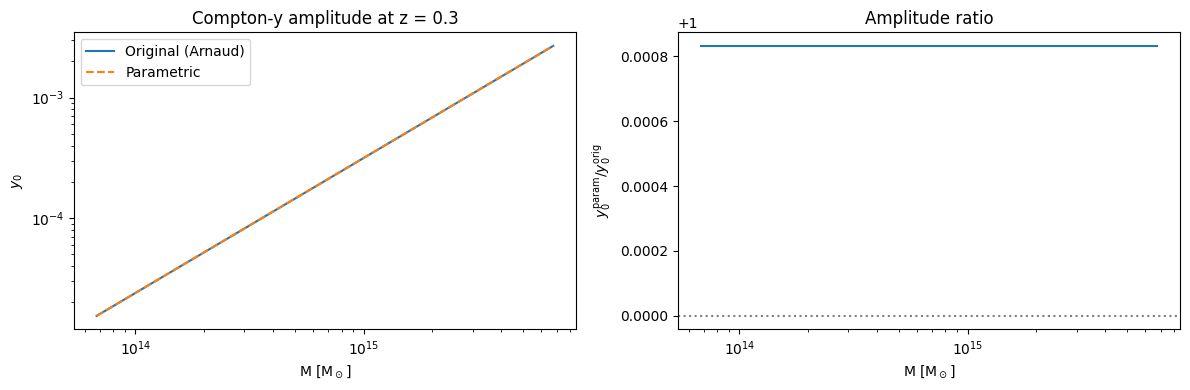

In [5]:
from tszpower.parametric_profile import compute_y0_parametric, compute_snr_parametric
from tszpower.maskedpower import compute_y0, compute_snr

z_test = 0.3
M_test = jnp.geomspace(1e14*0.6766, 1e16*0.6766, 50)

# Vectorise over mass
y0_orig = jax.vmap(lambda m: compute_y0(m, z_test, params_values_dict=allpars))(M_test)
y0_param = jax.vmap(
    lambda m: compute_y0_parametric(m, z_test, A_SZ, alpha_SZ, params_values_dict=allpars)
)(M_test)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(M_test, y0_orig, label='Original (Arnaud)')
ax1.loglog(M_test, y0_param, '--', label='Parametric')
ax1.set_xlabel('M [M$_\\odot$]')
ax1.set_ylabel('$y_0$')
ax1.set_title(f'Compton-y amplitude at z = {z_test}')
ax1.legend()

ax2.semilogx(M_test, y0_param / y0_orig)
ax2.set_xlabel('M [M$_\\odot$]')
ax2.set_ylabel('$y_0^{\\rm param} / y_0^{\\rm orig}$')
ax2.set_title('Amplitude ratio')
ax2.axhline(1, ls=':', c='grey')

plt.tight_layout()
plt.show()

## 3. Total (Full-Sky) tSZ Power Spectrum

Compute the **unmasked** tSZ $C_\ell$ and $D_\ell$ with the parametric amplitude,
and compare to the original Arnaud profile.

In [6]:
from tszpower.parametric_profile import (
    compute_tsz_ps_parametric,
    compute_tsz_Dell_parametric,
    compute_tsz_Dell_binned_parametric,
)
from tszpower.tsz import compute_integral
from tszpower.utils import get_ell_range

ell = get_ell_range()

# --- Original (Arnaud) ---
C_ell_orig = compute_integral(params_values_dict=allpars)
D_ell_orig = ell * (ell + 1) * C_ell_orig / (2 * jnp.pi) * 1e12

# --- Parametric ---
C_ell_param = compute_tsz_ps_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
)
D_ell_param = compute_tsz_Dell_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
)

print(f"C_ell shape: {C_ell_param.shape}")
print(f"D_ell shape: {D_ell_param.shape}")

C_ell shape: (50,)
D_ell shape: (50,)


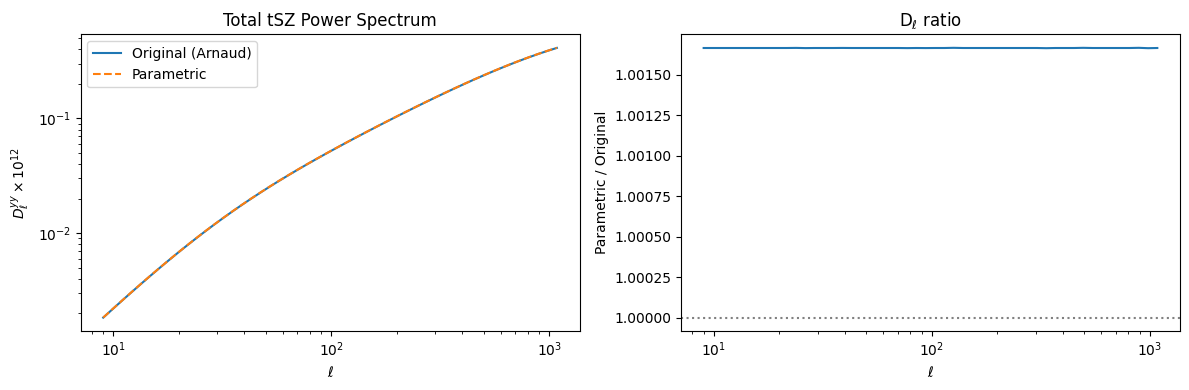

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(ell, D_ell_orig, label='Original (Arnaud)')
ax1.loglog(ell, D_ell_param, '--', label='Parametric')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'$D_\ell^{yy} \times 10^{12}$')
ax1.set_title('Total tSZ Power Spectrum')
ax1.legend()

ax2.semilogx(ell, D_ell_param / D_ell_orig)
ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel('Parametric / Original')
ax2.set_title('D$_\\ell$ ratio')
ax2.axhline(1, ls=':', c='grey')

plt.tight_layout()
plt.show()

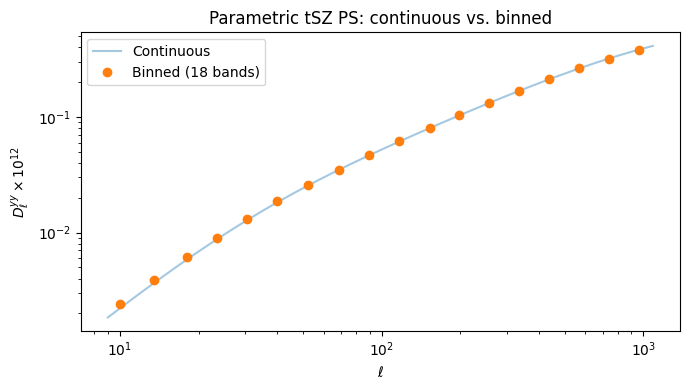

In [8]:
# Binned D_ell (18 Planck-style bands)
D_ell_binned = compute_tsz_Dell_binned_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
)

from tszpower.maskedpower import ELL_EFF

plt.figure(figsize=(7, 4))
plt.loglog(ell, D_ell_param, 'C0-', alpha=0.4, label='Continuous')
plt.loglog(ELL_EFF, D_ell_binned, 'C1o', ms=6, label='Binned (18 bands)')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{yy} \times 10^{12}$')
plt.title('Parametric tSZ PS: continuous vs. binned')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Masked (Unresolved) tSZ Power Spectrum

After masking clusters above SNR threshold $q_{\rm cat}$, the residual
power spectrum uses the completeness weight $W = 1 - P_{\rm det}$,
where $P_{\rm det}$ accounts for both intrinsic scatter and instrumental noise.

In [9]:
from tszpower.parametric_profile import (
    compute_masked_tsz_ps_parametric,
    compute_masked_tsz_Dell_parametric,
    compute_masked_tsz_Dell_binned_parametric,
)

# Masked (unresolved) D_ell with parametric amplitude
D_ell_masked = compute_masked_tsz_Dell_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
    q_cat=q_cat,
    sigma_lnY=sigma_lnY,
)

# Binned version
D_ell_masked_binned = compute_masked_tsz_Dell_binned_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
    q_cat=q_cat,
    sigma_lnY=sigma_lnY,
)

print(f"D_ell masked (continuous) shape: {D_ell_masked.shape}")
print(f"D_ell masked (binned) shape:     {D_ell_masked_binned.shape}")

D_ell masked (continuous) shape: (50,)
D_ell masked (binned) shape:     (18,)


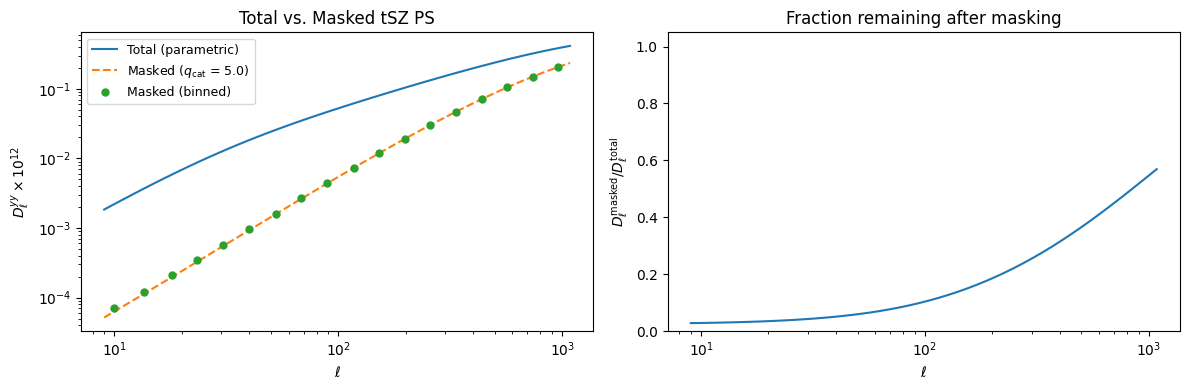

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.loglog(ell, D_ell_param, label='Total (parametric)')
ax1.loglog(ell, D_ell_masked, '--', label=f'Masked ($q_{{\\rm cat}}$ = {q_cat})')
ax1.loglog(ELL_EFF, D_ell_masked_binned, 'o', ms=5, label='Masked (binned)')
ax1.set_xlabel(r'$\ell$')
ax1.set_ylabel(r'$D_\ell^{yy} \times 10^{12}$')
ax1.set_title('Total vs. Masked tSZ PS')
ax1.legend(fontsize=9)

ax2.semilogx(ell, D_ell_masked / D_ell_param)
ax2.set_xlabel(r'$\ell$')
ax2.set_ylabel(r'$D_\ell^{\rm masked} / D_\ell^{\rm total}$')
ax2.set_title('Fraction remaining after masking')
ax2.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

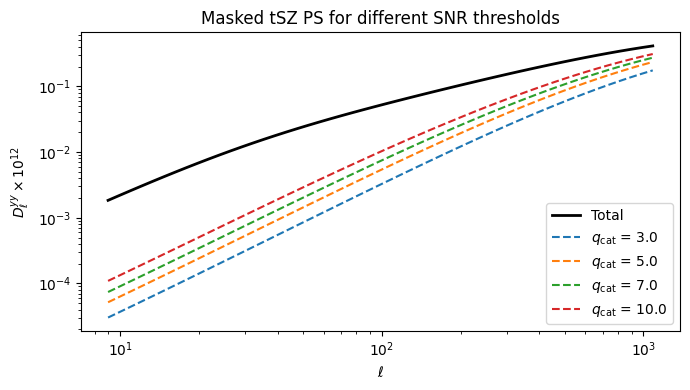

In [11]:
# --- Effect of varying q_cat ---
plt.figure(figsize=(7, 4))
plt.loglog(ell, D_ell_param, 'k-', lw=2, label='Total')

for q in [3.0, 5.0, 7.0, 10.0]:
    D_masked_q = compute_masked_tsz_Dell_parametric(
        params_values_dict=allpars,
        A_SZ=A_SZ, alpha_SZ=alpha_SZ,
        q_cat=q, sigma_lnY=sigma_lnY,
    )
    plt.loglog(ell, D_masked_q, '--', label=f'$q_{{\\rm cat}}$ = {q}')

plt.xlabel(r'$\ell$')
plt.ylabel(r'$D_\ell^{yy} \times 10^{12}$')
plt.title('Masked tSZ PS for different SNR thresholds')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Total Number of Resolved Clusters

Compute the total number of detected clusters above the SNR threshold $q_{\rm cat}$,
using the full double-scatter completeness.

In [12]:
from tszpower.parametric_profile import compute_number_detected_clusters_parametric

N_det = compute_number_detected_clusters_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
    q_cat=q_cat,
    sigma_lnY=sigma_lnY,
    f_sky=f_sky,
)

print(f"Number of detected clusters (q_cat={q_cat}, f_sky={f_sky}): {N_det:.1f}")

Number of detected clusters (q_cat=5.0, f_sky=1.0): 1328.1


q_cat =   3.0  =>  N_det =   5378.3
q_cat =   4.0  =>  N_det =   2267.5
q_cat =   5.0  =>  N_det =   1328.1
q_cat =   6.0  =>  N_det =    877.6
q_cat =   7.0  =>  N_det =    619.2
q_cat =   8.0  =>  N_det =    456.7
q_cat =  10.0  =>  N_det =    272.3
q_cat =  15.0  =>  N_det =    102.3
q_cat =  20.0  =>  N_det =     49.2


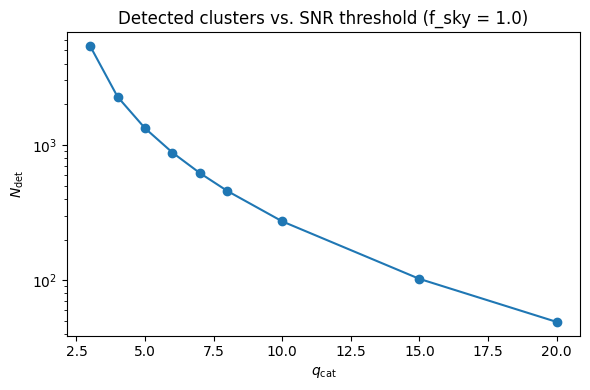

In [13]:
# --- N_det as a function of q_cat ---
q_vals = np.array([3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 10.0, 15.0, 20.0])
N_vals = []

for q in q_vals:
    N = compute_number_detected_clusters_parametric(
        params_values_dict=allpars,
        A_SZ=A_SZ, alpha_SZ=alpha_SZ,
        q_cat=float(q), sigma_lnY=sigma_lnY,
        f_sky=f_sky,
    )
    N_vals.append(float(N))
    print(f"q_cat = {q:5.1f}  =>  N_det = {float(N):8.1f}")

plt.figure(figsize=(6, 4))
plt.semilogy(q_vals, N_vals, 'o-')
plt.xlabel(r'$q_{\rm cat}$')
plt.ylabel(r'$N_{\rm det}$')
plt.title(f'Detected clusters vs. SNR threshold (f_sky = {f_sky})')
plt.tight_layout()
plt.show()

## 6. Binned Cluster Counts in $(z, q)$ Bins

Bin the resolved clusters into redshift and SNR bins using the full
double-scatter completeness.

In [14]:
from tszpower.parametric_profile import (
    compute_cluster_counts_in_z_q_bins_parametric,
    compute_cluster_counts_2d_parametric,
)

In [15]:
# Define bin edges
z_edges = jnp.array([0.01, 0.1, 0.2, 0.3, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0])
q_edges = jnp.array([5.0, 6.0, 7.0, 8.0, 10.0, 15.0, 20.0, 50.0, 1000.0])

print(f"z bins: {len(z_edges)-1}")
print(f"q bins: {len(q_edges)-1}")

z bins: 9
q bins: 8


### 6a. 1D marginalised counts: $N(z)$ and $N(q)$

In [16]:
Nz, Nq = compute_cluster_counts_in_z_q_bins_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
    sigma_lnY=sigma_lnY,
    z_edges=z_edges,
    q_edges=q_edges,
    f_sky=f_sky,
)

print(f"N(z) shape: {Nz.shape}  =>  {[f'{n:.1f}' for n in Nz]}")
print(f"N(q) shape: {Nq.shape}  =>  {[f'{n:.1f}' for n in Nq]}")
print(f"Sum N(z) = {float(jnp.sum(Nz)):.1f}")
print(f"Sum N(q) = {float(jnp.sum(Nq)):.1f}")

N(z) shape: (9,)  =>  ['308.0', '396.1', '270.9', '162.3', '141.5', '37.1', '8.4', '2.0', '0.0']
N(q) shape: (8,)  =>  ['450.4', '258.5', '162.5', '184.4', '170.0', '53.1', '45.5', '3.7']
Sum N(z) = 1326.4
Sum N(q) = 1328.1


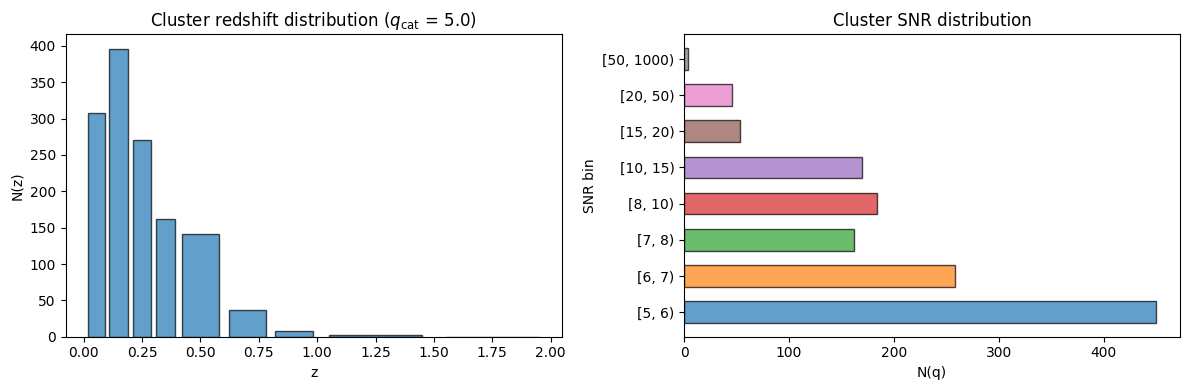

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# N(z)
z_mid = 0.5 * (z_edges[:-1] + z_edges[1:])
z_width = jnp.diff(z_edges)
ax1.bar(z_mid, Nz, width=0.8 * z_width, alpha=0.7, edgecolor='k')
ax1.set_xlabel('z')
ax1.set_ylabel('N(z)')
ax1.set_title(f'Cluster redshift distribution ($q_{{\\rm cat}}$ = {q_cat})')

# N(q)
q_mid = 0.5 * (q_edges[:-1] + q_edges[1:])
for j in range(len(Nq)):
    ax2.barh(
        j, float(Nq[j]), height=0.6, alpha=0.7, edgecolor='k',
    )
ax2.set_yticks(range(len(Nq)))
ax2.set_yticklabels([f'[{float(q_edges[j]):.0f}, {float(q_edges[j+1]):.0f})'
                      for j in range(len(Nq))])
ax2.set_xlabel('N(q)')
ax2.set_ylabel('SNR bin')
ax2.set_title('Cluster SNR distribution')

plt.tight_layout()
plt.show()

### 6b. 2D binned counts: $N(z_i, q_j)$

In [18]:
N2d = compute_cluster_counts_2d_parametric(
    params_values_dict=allpars,
    A_SZ=A_SZ,
    alpha_SZ=alpha_SZ,
    sigma_lnY=sigma_lnY,
    z_edges=z_edges,
    q_edges=q_edges,
    f_sky=f_sky,
)

print(f"N2d shape: {N2d.shape}")
print(f"Total clusters (sum of 2D grid): {float(jnp.sum(N2d)):.1f}")

N2d shape: (9, 8)
Total clusters (sum of 2D grid): 1326.4


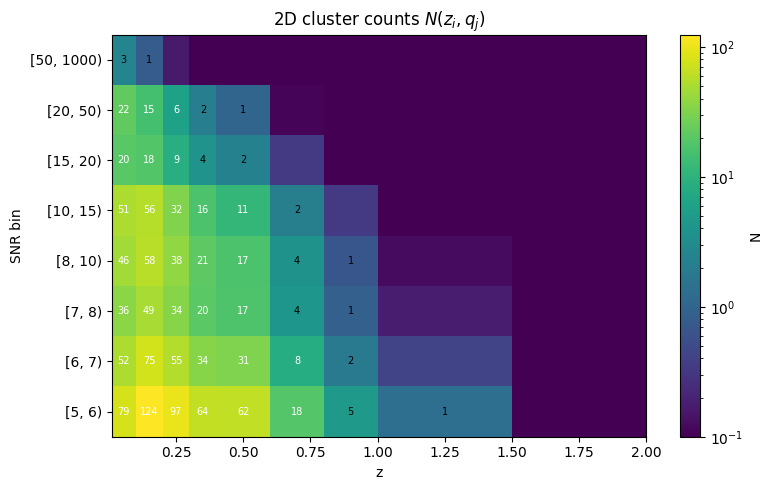

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))

N2d_np = np.array(N2d)
# Use log scale for colour, floor at 0.1 for display
N2d_plot = np.maximum(N2d_np, 0.1)

im = ax.pcolormesh(
    np.array(z_edges),
    np.arange(len(q_edges)),
    N2d_plot.T,
    shading='flat',
    cmap='viridis',
    norm=plt.matplotlib.colors.LogNorm(vmin=0.1),
)

ax.set_yticks(np.arange(len(q_edges) - 1) + 0.5)
ax.set_yticklabels([f'[{float(q_edges[j]):.0f}, {float(q_edges[j+1]):.0f})'
                     for j in range(len(q_edges) - 1)])
ax.set_xlabel('z')
ax.set_ylabel('SNR bin')
ax.set_title(r'2D cluster counts $N(z_i, q_j)$')

cbar = plt.colorbar(im, ax=ax, label='N')

# Annotate each cell with the count
z_mid_np = np.array(z_mid)
for i in range(N2d_np.shape[0]):
    for j in range(N2d_np.shape[1]):
        val = N2d_np[i, j]
        if val >= 0.5:
            ax.text(
                z_mid_np[i], j + 0.5, f'{val:.0f}',
                ha='center', va='center', fontsize=7,
                color='white' if val > 5 else 'black',
            )

plt.tight_layout()
plt.show()

## Summary

| Calculation | Function | Key args |
|---|---|---|
| Parametric $y_0$ | `compute_y0_parametric` | `A_SZ`, `alpha_SZ` |
| Parametric SNR | `compute_snr_parametric` | `A_SZ`, `alpha_SZ` |
| Total tSZ $C_\ell$ | `compute_tsz_ps_parametric` | `A_SZ`, `alpha_SZ` |
| Total tSZ $D_\ell$ | `compute_tsz_Dell_parametric` | `A_SZ`, `alpha_SZ` |
| Total tSZ $D_\ell$ (18 bins) | `compute_tsz_Dell_binned_parametric` | `A_SZ`, `alpha_SZ` |
| Masked $C_\ell$ | `compute_masked_tsz_ps_parametric` | `A_SZ`, `alpha_SZ`, `q_cat`, `sigma_lnY` |
| Masked $D_\ell$ | `compute_masked_tsz_Dell_parametric` | `A_SZ`, `alpha_SZ`, `q_cat`, `sigma_lnY` |
| Masked $D_\ell$ (18 bins) | `compute_masked_tsz_Dell_binned_parametric` | `A_SZ`, `alpha_SZ`, `q_cat`, `sigma_lnY` |
| Total $N_{\rm det}$ | `compute_number_detected_clusters_parametric` | `A_SZ`, `alpha_SZ`, `q_cat`, `sigma_lnY`, `f_sky` |
| $N(z)$, $N(q)$ | `compute_cluster_counts_in_z_q_bins_parametric` | + `z_edges`, `q_edges` |
| $N(z_i, q_j)$ 2D | `compute_cluster_counts_2d_parametric` | + `z_edges`, `q_edges` |